# Image Segmentation on anevrisms

## 1. Applying image filtering

Some of the anevrisms are already segmented (patient 2 and patient 3): to remove the segmentation, one can apply a mean filter on the segmentaiton line: the idea is to remove the segmentation line, then replace its value with the value of a 2*2 mean filter

In [2]:
!pip install scikit-image

  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 5.9 MB/s eta 0:00:00a 0:00:01
Using cached networkx-3.6.1-py3-none-any.whl (2.1 MB)


In [3]:
!ls imgs

STD_AOST_PreStent.tif  patient1_seg.tif  patient3.tif
patient1_no_seg.bmp    patient2.tif


/home/user/miniconda3/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/user/miniconda3/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_20931/946815876.py:27: RuntimeWarning: invalid value encountered in cast
  img2[pixelx,pixely] = np.mean(mean_list, axis=0)


Text(0.5, 1.0, 'anv3')

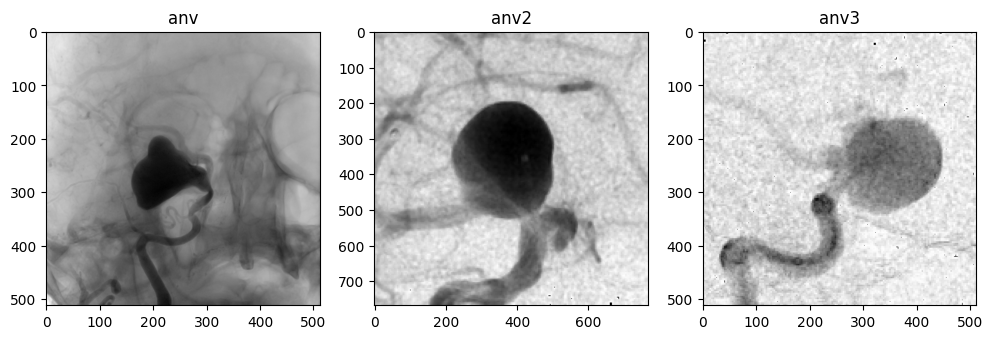

In [11]:
from skimage import graph, data, io, segmentation, color
import os
from matplotlib import pyplot as plt
from skimage.measure import regionprops
from skimage import draw
import numpy as np

anv = io.imread(os.path.join('imgs', 'patient1_no_seg.bmp'))
anv2 = io.imread(os.path.join('imgs', 'patient2.tif'))
anv3 = io.imread(os.path.join('imgs', 'patient3.tif'))
#anv = color.gray2rgb(anv)

def remove_seg(img):
    """return an image without its segmentations, using a mean filter.
    Mean filter 2*2 is applied only on the segmenation, leaving the rest as it is"""
    img2 = img.copy()
    for pixelx in range(img.shape[0]):
        for pixely in range(img.shape[1]):
    #         if np.all(img[pixelx,pixely]==np.array([0,255,255])) or np.all(img[pixelx,pixely]==np.array([0,255,0])) or\
    #         np.all(img[pixelx,pixely]==np.array([255,255,0])) or np.all(img[pixelx,pixely]==np.array([255,0,255])):
            if np.any(img[pixelx,pixely]==np.array([255,255,255])):
                mean_list = []
                for px in range(pixelx-1,pixelx+2):
                    for py in range(pixely-1, pixely+2):
                        if px < img.shape[0] and py < img.shape[1] and not np.any(img[px,py]==[255,255,255]) :
                            mean_list.append(img[px,py])

                    img2[pixelx,pixely] = np.mean(mean_list, axis=0)
        
    return img2

seg_ref_anv2 = anv2.copy()
anv2 = remove_seg(anv2)
anv3 = remove_seg(anv3)
fig, ax = plt.subplots(ncols=3, figsize=(12, 16))
ax[0].imshow(color.gray2rgb(anv))
ax[0].set_title("anv")
ax[1].imshow(anv2)
ax[1].set_title("anv2")
seg_ref_anv2_2 = seg_ref_anv2 * (seg_ref_anv2 == [0,255,0])

ax[2].imshow(anv3)
ax[2].set_title("anv3")
